User guide :

It is prudent to test the competitive behavior of pairs of species to ensure that the behavior is appropriate. I recommend that you conduct some tests of two and/or three species combinations using your calibration setup to ensure that species compete as you would expect. Extremely poor competitive ability usually results only when a cohort is inappropriately overtopped by another and becomes lightstarved. Some users conduct tests (or even calibrate concurrently) on different soil types, which is especially useful for checking growth under waterlogged and drought conditions. Small tweaks to the H parameters can often greatly improve performance on those soils while having little effect on performance on the mesic soil. Anomalies can be corrected with modest tweaks of one or two parameters to ensure that the cohorts grow sufficiently similar to remain in the same canopy layer. You can also adjust the LayerThreshRatio parameters if needed to achieve desired canopy layering behavior. The currently recommended value is 0.5, but you may find that another value is better (e.g., 0.67).

Again, to ensure realistic competition, it is advisable to use common parameter values across species as much as possible, unless you have empirical data that are comparable and reliable across species. If you are planning to experimentally vary some parameters, holding the others constant will improve the signal from your experiment.

Minimizing species differences in parameters such as SLWDel, PsnAgeRed, k, MaintResp, DNSC and FracBelowG, will make competitive interactions more predictable. Hold these as close to each other as possible, varying other parameters to calibrate as much as possible within empirical limits. However, when you cannot calibrate adequately using the common parameter values, do not hesitate to vary the one or two other parameters that will produce good performance. It is very likely that such modifications reflect biological reality. 2) Use the PnET-Succession function worksheet to help you understand how the parameters determine the behavior of cohort state variables as a function of the abiotic inputs, both intermediate variables and the ones that ultimately reflect competition and growth (e.g., NetPsn, foliar and wood biomass, NSCfrac). It is available from the PnET-Succession page of the LANDIS-II website (www.landis-ii.org). 3) It is highly recommended that you verify your calibrations by simulating several similar species together to ensure that they in fact compete as expected. If not, often a slight tweak of one parameter can bring them in line with expectations.

To produce predictable competitive interactions that can be controlled by intuitive modification of a small number of parameters for individual species, it is helpful to use common parameter values across all species whenever possible. These can be conveniently maintained (and modified as necessary) in the GenericPnETSpeciesParameters file. Other parameters vary by life history trait or growth form, and each species having a particular life history trait should have the same (or similar) parameter value to represent that trait. Examples of such traits include shade tolerance (HalfSat), drought tolerance (H3 & H4), extinction coefficient (k), relationship between foliar N and photosynthetic capacity (AmaxA and AmaxB), leaf weight change by canopy position (SLWdel) and fraction of foliar biomass relative to active wood biomass (FracFol). Parameters that the model is highly sensitive to (for which common values should be used as much as possible) include: MaintResp, AmaxA, AmaxB, k, and FracBelowG.

MaintResp is a critical parameter for PnET-Succession because it is the primary determinant of cohort growth limitations and death, and growth is highly sensitive to variation in this parameter. Unfortunately, this parameter is rarely known empirically in the units used by the model, so it must be calibrated. If MaintResp is too low, cohorts will never die from stress and growth will be virtually unconstrained. If MaintResp is too high, growth will quickly level off because of high maintenance costs and cohorts will be highly susceptible to stress. For most studies, competitive outcomes should be a function of competition for light and water, not from a difference in maintenance costs. Therefore, it is recommended to find a value for MaintResp that works across life history traits and growth forms. This is fairly easily done. Choose some representative species having generic growth parameters (including great longevity) and simulate their growth curves, searching for a value of MaintResp that flattens (levels off) the growth curve after a few decades. Then gradually reduce MaintResp until the growth curve takes the shape of that typically seen in the growth curves of your long-lived species. Select a value of MaintResp that produces acceptable behavior for all life forms, etc., and use it for all species. In summary, you are searching for a value that is as high as it can be without creating a flattened growth curve. Values that work well for many temperate ecosystems are between 0.0015 and 0.002.

## Testing competition scripts

Objectives :

For one combo of species (*Abies balsamea*  versus * Acer rubrum*), do a competition for shade.

- Read the PnET test scenario files
- Load the initial parameters for the species (step 1 not done yet)
- Edit parameters of PnET test scenario files to insert initial parameters
- Create raster maps for initial communities, ecoregions
- Insert historical data ?
- Finish preparing scenario file, etc. in the dict
- Write the files (including the right rasters) in a temp folder
- Do the simulation
- Read the outputs.

In [8]:
from functionsForCalibration import *
import shutil

PnETGitHub_OneCellSim = parse_All_LANDIS_PnET_Files(r"./SimulationFiles/PnETGitHub_OneCellSim_v8")
# for key in PnETGitHub_OneCellSim:
#     print("\n\n File : " + str(key))
#     print(PnETGitHub_OneCellSim[key])
# print("\n\n\nHere is the content of the Python dictionnary containing all of the parsed parameters :\n\n" + str(PnETGitHub_OneCellSim))

import json

# To change :

# - ecoregion.txt ; change soil of eco1 to SILO
PnETGitHub_OneCellSim["EcoregionParameters.txt"]["EcoregionParameters"]["eco1"]["SoilType"] = "SILO"

# - pnetsuccession.txt : change startyear to 1910 and latitude to village of Manawan (47.2223) and no dispersal
PnETGitHub_OneCellSim["pnetsuccession.txt"]["StartYear"] = "1910"
PnETGitHub_OneCellSim["pnetsuccession.txt"]["Latitude"] = "47.2223"
PnETGitHub_OneCellSim["pnetsuccession.txt"]["SeedingAlgorithm"] = "NoDispersal"

# - scenario.txt : put a duration of 100, cell length of 100
PnETGitHub_OneCellSim["scenario.txt"]["Duration"] = "1000"
PnETGitHub_OneCellSim["scenario.txt"]["CellLength"] = "100"

# - Species.txt : replace with the right initial core species parameters from the JSON file
with open('./SpeciesParametersSets/Initial/initialCoreSpeciesParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["species.txt"] = json.load(f)

# - SpeciesParameters.txt : replace with the initial PnET species parameters from the JSOn file
with open('./SpeciesParametersSets/Initial/initialPnETSpeciesParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["SpeciesParameters.txt"] = json.load(f)

# - PnETGenericParameters.txt : replace with initial generic parameters from the JSON file
with open('./SpeciesParametersSets/Initial/InitialGenericParameters.json', 'r') as f:
    PnETGitHub_OneCellSim["PnETGenericParameters.txt"] = json.load(f)

# -  PnEToutputsites_onecell.txt : replace site location
PnETGitHub_OneCellSim["PnEToutputsites_onecell.txt"]["Site1"] = '1 1'

# Enabling universal dispersal so that there can be some corhort reproduction; that the cohorts are not "locked" at the beginning of the sim.
# That's the best way I've found so that there can be new cohort sprouting in every cells, without introducing neighbor interactions
# Universal dispersal is neighbor-independant. See https://drive.google.com/file/d/15gSueug-Rj9I2RZqdroDbad-k53Jq7j3/view
PnETGitHub_OneCellSim["pnetsuccession.txt"]["SeedingAlgorithm"] = "UniversalDispersal"
# Enabling establishment in generic parameter file
PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["PreventEstablishment"] = "False"

# Insert climate for Manawan derived from Ouranos datasets (see 5.Getting_climate_and_soil_data.ipynb)
PnETGitHub_OneCellSim["pnetsuccession.txt"]["ClimateConfigFile"] = "ClimateConfigSimpleSims_MonthlyAveraged.txt"

# Removing Picea mariana from the simulation
del PnETGitHub_OneCellSim["species.txt"]["PICE.MAR"]
del PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]["PICE.MAR"]

# Change canopy layering
PnETGitHub_OneCellSim["PnETGenericParameters.txt"]["LayerThreshRatio"] = 0.5

# Decreasing or increasing the k exctinction coefficient for light of everybody to help younger cohorts survive.
# for species in PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"]:
#     PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["k"] = str(float(PnETGitHub_OneCellSim["SpeciesParameters.txt"]["PnETSpeciesParameters"][species]["k"]) * 0.7)

# Writing the files in a temporary folder
testScenarioPath = "/tmp/TestScenarioPnET/"

# We create the folder
if not os.path.exists(testScenarioPath):
    os.mkdir(testScenarioPath)
else:
    shutil.rmtree(testScenarioPath)
    os.mkdir(testScenarioPath)

write_all_LANDIS_files(testScenarioPath,
                       PnETGitHub_OneCellSim,
                       True)


numberOfCells = 100
ageRange = [10, 50]

# After writing the files
from rasterio.transform import Affine

# Copy the climate config file and climate file
import shutil
shutil.copy("./SimulationFiles/ClimateConfigSimpleSims_MonthlyAveraged.txt", testScenarioPath)
shutil.copy("./ReferencesAndData/Climate Data/dataFrameClimate_historicalMonthly_Ouranos_MonthlyAveraged.csv", testScenarioPath)
shutil.copy("./ReferencesAndData/Climate Data/dataFrameClimate_SpinupMonthly_Ouranos_MonthlyAveraged.csv", testScenarioPath)

# - ecoregion.img; put eco1 everywhere (1)

# Create array with 1 row and 1000 columns, filled with 1
data = np.ones((1, numberOfCells), dtype=np.uint8)

# Define transform (pixel size and origin)
transform = Affine.translation(0, 0) * Affine.scale(1, 1)

# Write raster
with rasterio.open(
    testScenarioPath + '/ecoregion.img',
    'w',
    driver='GTiff',
    height=1,
    width=numberOfCells,
    count=1,
    dtype=data.dtype,
    crs='EPSG:4326',
    transform=transform
) as dst:
    dst.write(data, 1)


# - Initial community raster; one line, from 1 to 1001
# Create array of 1 to 1001 cells filled with 1
data = np.arange(1, numberOfCells+1, dtype="int32").reshape(1, numberOfCells)

# Write raster
with rasterio.open(
    testScenarioPath + '/initial-communities.img',
    'w',
    driver='GTiff',
    height=1,
    width=numberOfCells,
    count=1,
    dtype=data.dtype,
    crs='EPSG:4326',
    transform=transform
) as dst:
    dst.write(data, 1)


# - Initial community .csv; one random entry per mapcode
import random
import csv

def create_species_csv(species_tuple, filename='output.csv'):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile, delimiter=',')

        # Write header
        writer.writerow(['MapCode', 'SpeciesName', 'CohortAge', 'CohortBiomass'])

        # Loop through MapCode 1 to 1001
        for map_code in range(1, numberOfCells+2):
            # Write one row for each species
            for species in species_tuple:
                random_age = random.randint(ageRange[0], ageRange[1])
                writer.writerow([map_code, species, random_age, 0])

# Example usage
species = ("ABIE.BAL", "ACER.RUB")
create_species_csv(species, filename = testScenarioPath + "/initial-communities.csv")

# We launch the simulation
runLANDIS_Simulation("/tmp/TestScenarioPnET/",
                     "scenario.txt",
                    False)

Found : Additional file : !Run_scenario.bat
Found : PnET OutputBiomass parameter file : biomass.outputPnET.txt
Found : Climate file : climate.txt
Found : Disturbance Reduction File : disturbance_reductions.txt
Found : Additional file : ecoregion.img
Found : Main ecoregions file : ecoregion.txt
Found : PnET Ecoregion parameter file : EcoregionParameters.txt
Found : Initial Communities file : initial-communities.csv
Found : Additional file : initial-communities.img
Found : PnET generic parameter file : PnETGenericParameters.txt
Found : PnET OutputSites parameter file : PnEToutputsites_onecell.txt
Found : Main PnET parameter file : pnetsuccession.txt
Found : Additional file : README.txt
Found : Main scenario file : scenario.txt
Found : Main species parameter file : species.txt
Found : PnET species parameters file : SpeciesParameters.txt
Found : Additional file : !Run_scenario.bat
Found : PnET OutputBiomass parameter file : biomass.outputPnET.txt
Found : Climate file : climate.txt
Found : 

/usr/local/lib/python3.10/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


The LANDIS-II simulation has finished properly!


Detected species: ['ACER.RUB', 'ABIE.BAL']


/usr/local/lib/python3.10/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


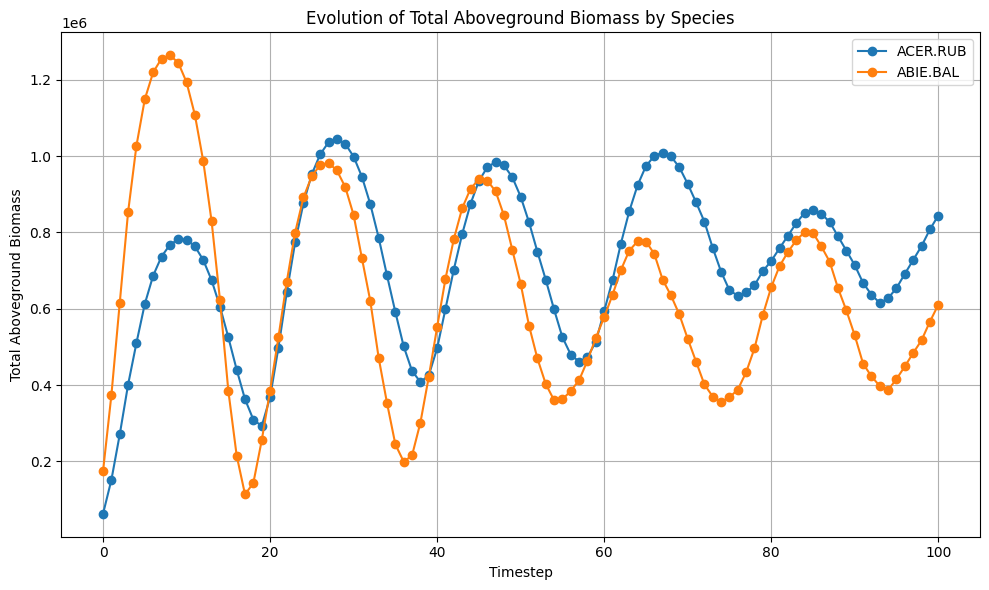


=== Competition Analysis: ABIE.BAL vs ACER.RUB ===



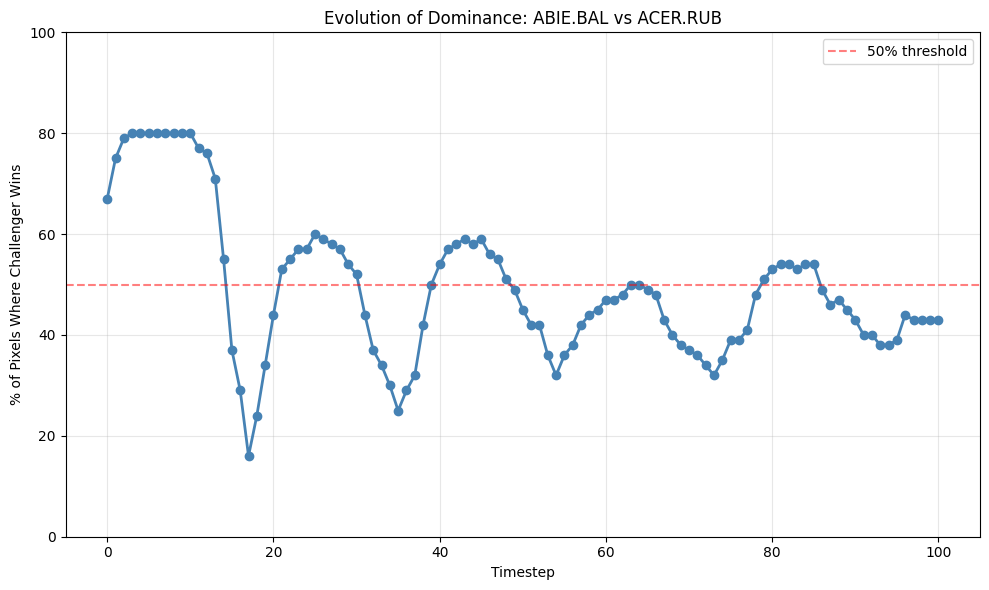

Method 1 - Absolute Biomass at End:
  ABIE.BAL wins in 43.00% of pixels
  (43 out of 100 pixels)

Method 2 - Relative Ratio Improvement:
  ABIE.BAL wins in 32.00% of pixels
  (32 out of 100 pixels)


In [9]:
# Now, we read the biomass rasters (wood + foliage)
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
outputPath = "/tmp/TestScenarioPnET/output"  # Modify this path
challengingSpecies = "ABIE.BAL"  # Modify species name
opponentSpecies = "ACER.RUB"  # Modify species name

# Detect species folders
wood_biomass_path = os.path.join(outputPath, "WoodBiomass")
foliage_biomass_path = os.path.join(outputPath, "FoliageBiomass")

species_folders = [f for f in os.listdir(wood_biomass_path) 
                   if os.path.isdir(os.path.join(wood_biomass_path, f)) and f != "AllSpecies"]

print(f"Detected species: {species_folders}")

# Function to get sorted raster files
def get_raster_files(base_path, species, biomass_type):
    species_path = os.path.join(base_path, species)
    files = [f for f in os.listdir(species_path) if f.endswith('.img')]
    # Sort by timestep number
    files.sort(key=lambda x: int(x.split('-')[1].split('.')[0]))
    return [os.path.join(species_path, f) for f in files]

# Compute total biomass evolution for each species
biomass_evolution = {}

for species in species_folders:
    wood_files = get_raster_files(wood_biomass_path, species, "WoodBiomass")
    foliage_files = get_raster_files(foliage_biomass_path, species, "FoliageBiomass")

    total_biomass = []

    for wood_file, foliage_file in zip(wood_files, foliage_files):
        with rasterio.open(wood_file) as wood_src:
            wood_data = wood_src.read(1)
        with rasterio.open(foliage_file) as foliage_src:
            foliage_data = foliage_src.read(1)

        # Sum wood and foliage, then sum across all pixels
        total = np.nansum(wood_data + foliage_data)
        total_biomass.append(total)

    biomass_evolution[species] = total_biomass

# Plot biomass evolution
plt.figure(figsize=(10, 6))
for species, biomass in biomass_evolution.items():
    timesteps = list(range(len(biomass)))
    plt.plot(timesteps, biomass, marker='o', label=species)

plt.xlabel('Timestep')
plt.ylabel('Total Aboveground Biomass')
plt.title('Evolution of Total Aboveground Biomass by Species')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Competition analysis between challenging and opponent species
print(f"\n=== Competition Analysis: {challengingSpecies} vs {opponentSpecies} ===\n")

# Get files for both species
challenger_wood = get_raster_files(wood_biomass_path, challengingSpecies, "WoodBiomass")
challenger_foliage = get_raster_files(foliage_biomass_path, challengingSpecies, "FoliageBiomass")
opponent_wood = get_raster_files(wood_biomass_path, opponentSpecies, "WoodBiomass")
opponent_foliage = get_raster_files(foliage_biomass_path, opponentSpecies, "FoliageBiomass")

# Track win percentage over time
timesteps = []
win_percentages = []

for i, (c_wood, c_foliage, o_wood, o_foliage) in enumerate(zip(challenger_wood, challenger_foliage, 
                                                                 opponent_wood, opponent_foliage)):
    with rasterio.open(c_wood) as src:
        challenger_wood_data = src.read(1)
    with rasterio.open(c_foliage) as src:
        challenger_foliage_data = src.read(1)
    with rasterio.open(o_wood) as src:
        opponent_wood_data = src.read(1)
    with rasterio.open(o_foliage) as src:
        opponent_foliage_data = src.read(1)

    challenger_biomass = challenger_wood_data + challenger_foliage_data
    opponent_biomass = opponent_wood_data + opponent_foliage_data

    # Calculate win percentage
    win_mask = challenger_biomass > opponent_biomass
    valid_pixels = ~np.isnan(challenger_biomass) & ~np.isnan(opponent_biomass)
    win_count = np.sum(win_mask & valid_pixels)
    total_pixels = np.sum(valid_pixels)
    win_pct = (win_count / total_pixels) * 100 if total_pixels > 0 else 0

    timesteps.append(i)
    win_percentages.append(win_pct)

# Plot win percentage evolution
plt.figure(figsize=(10, 6))
plt.plot(timesteps, win_percentages, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Timestep')
plt.ylabel('% of Pixels Where Challenger Wins')
plt.title(f'Evolution of Dominance: {challengingSpecies} vs {opponentSpecies}')
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Load first timestep (beginning)
with rasterio.open(challenger_wood[0]) as src:
    challenger_wood_start = src.read(1)
with rasterio.open(challenger_foliage[0]) as src:
    challenger_foliage_start = src.read(1)
with rasterio.open(opponent_wood[0]) as src:
    opponent_wood_start = src.read(1)
with rasterio.open(opponent_foliage[0]) as src:
    opponent_foliage_start = src.read(1)

challenger_biomass_start = challenger_wood_start + challenger_foliage_start
opponent_biomass_start = opponent_wood_start + opponent_foliage_start

# Load last timestep (end)
with rasterio.open(challenger_wood[-1]) as src:
    challenger_wood_end = src.read(1)
with rasterio.open(challenger_foliage[-1]) as src:
    challenger_foliage_end = src.read(1)
with rasterio.open(opponent_wood[-1]) as src:
    opponent_wood_end = src.read(1)
with rasterio.open(opponent_foliage[-1]) as src:
    opponent_foliage_end = src.read(1)

challenger_biomass_end = challenger_wood_end + challenger_foliage_end
opponent_biomass_end = opponent_wood_end + opponent_foliage_end

# Method 1: Absolute biomass comparison at end
win_absolute = challenger_biomass_end > opponent_biomass_end
total_pixels = np.sum(~np.isnan(challenger_biomass_end) & ~np.isnan(opponent_biomass_end))
win_count_absolute = np.sum(win_absolute)
win_percentage_absolute = (win_count_absolute / total_pixels) * 100

print(f"Method 1 - Absolute Biomass at End:")
print(f"  {challengingSpecies} wins in {win_percentage_absolute:.2f}% of pixels")
print(f"  ({win_count_absolute} out of {total_pixels} pixels)\n")

# Method 2: Relative ratio improvement
# Calculate ratio at start and end (challenger / opponent)
# Avoid division by zero
epsilon = 1e-10
ratio_start = challenger_biomass_start / (opponent_biomass_start + epsilon)
ratio_end = challenger_biomass_end / (opponent_biomass_end + epsilon)

# Challenger wins if ratio increased
win_relative = ratio_end > ratio_start
valid_pixels = ~np.isnan(ratio_start) & ~np.isnan(ratio_end) & np.isfinite(ratio_start) & np.isfinite(ratio_end)
win_count_relative = np.sum(win_relative & valid_pixels)
total_valid_pixels = np.sum(valid_pixels)
win_percentage_relative = (win_count_relative / total_valid_pixels) * 100

print(f"Method 2 - Relative Ratio Improvement:")
print(f"  {challengingSpecies} wins in {win_percentage_relative:.2f}% of pixels")
print(f"  ({win_count_relative} out of {total_valid_pixels} pixels)")

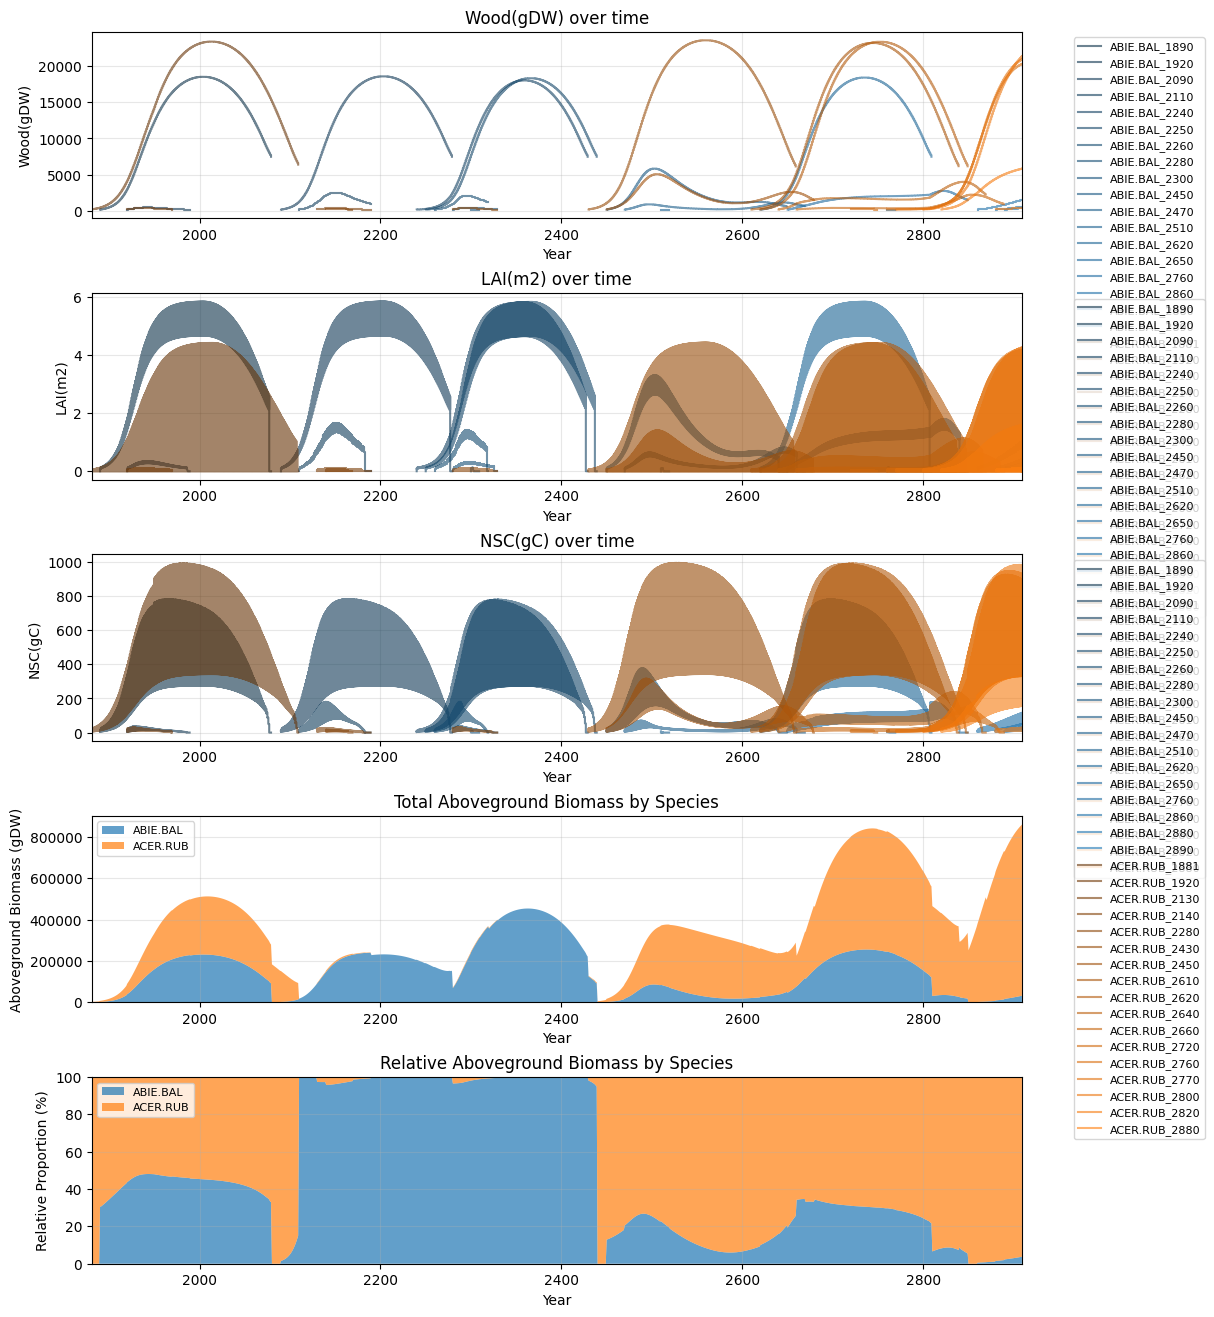

,Time,Year,Month,Age(yr),TopLayer(-),CanopyLayerProp,CanopyGrowingSpace,LAI(m2),SiteLAI(m2),GrossPsn(gC_m2_mo),...,AdjFolN(gN_gC),AdjFracFol(-),CiModifier(-),AdjHalfSat,LimitingFactor,Unnamed: 39,Cohort,Species,ImplantYear,AbovegroundBiomass
0,2610.00,2610,1,1,0,0.01294,1.0,0.0,0.0,0.0,...,2.32,0.014,1,181,fTemp,NaN,ACER.RUB_2610,ACER.RUB,2610,202.0
1,2610.08,2610,2,1,0,0.01294,1.0,0.0,0.0,0.0,...,2.32,0.014,1,181,fTemp,NaN,ACER.RUB_2610,ACER.RUB,2610,202.0
2,2610.17,2610,3,1,0,0.01294,1.0,0.0,0.0,0.0,...,2.32,0.014,1,181,fTemp,NaN,ACER.RUB_2610,ACER.RUB,2610,202.0
3,2610.25,2610,4,1,0,0.01294,1.0,0.0,0.0,0.0,...,2.32,0.014,1,181,fTemp,NaN,ACER.RUB_2610,ACER.RUB,2610,202.0
4,2610.33,2610,5,1,0,0.01294,1.0,0.0,0.0,0.0,...,2.32,0.014,1,181,fTemp,NaN,ACER.RUB_2610,ACER.RUB,2610,202.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51463,2319.58,2319,8,60,1,0.00000,1.0,0.0,0.0,0.0,...,1.00,0.070,1,134,fRad,NaN,ABIE.BAL_2260,ABIE.BAL,2260,1230.0
51464,2319.67,2319,9,60,1,0.00000,1.0,0.0,0.0,0.0,...,1.00,0.070,1,134,fRad,NaN,ABIE.BAL_2260,ABIE.BAL,2260,1230.0
51465,2319.75,2319,10,60,1,0.00000,1.0,0.0,0.0,0.0,...,1.00,0.070,1,134,fRad,NaN,ABIE.BAL_2260,ABIE.BAL,2260,1230.0
51466,2319.83,2319,11,60,1,0.00000,1.0,0.0,0.0,0.0,...,1.00,0.070,1,134,fTemp,NaN,ABIE.BAL_2260,ABIE.BAL,2260,1230.0


In [10]:
from functionsForCalibration import *

plot_all_cohort_results("/tmp/TestScenarioPnET/Output/Site1")

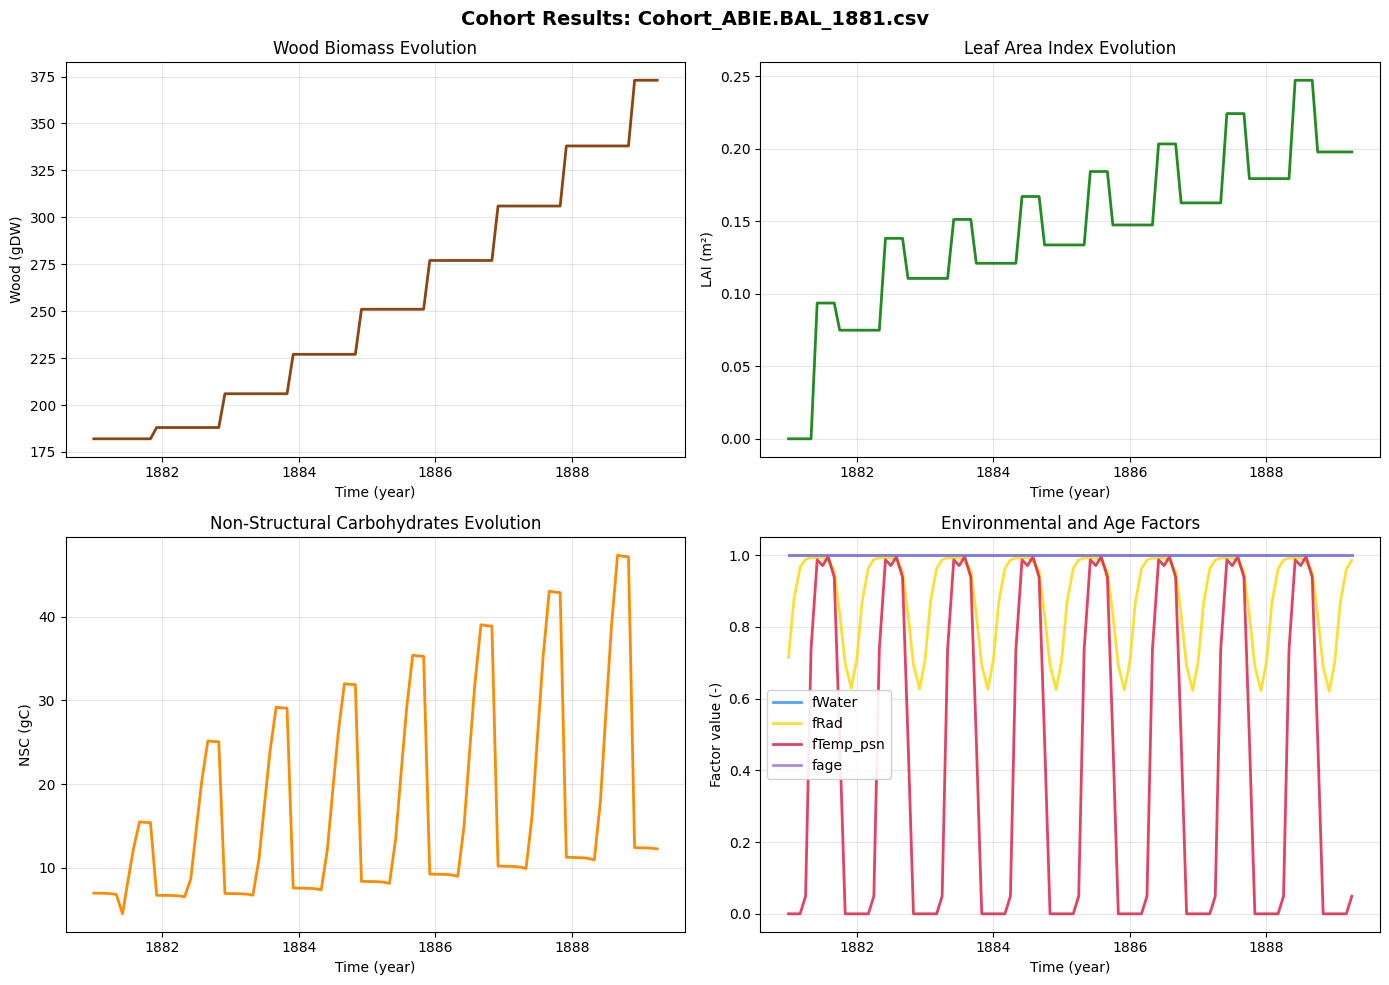

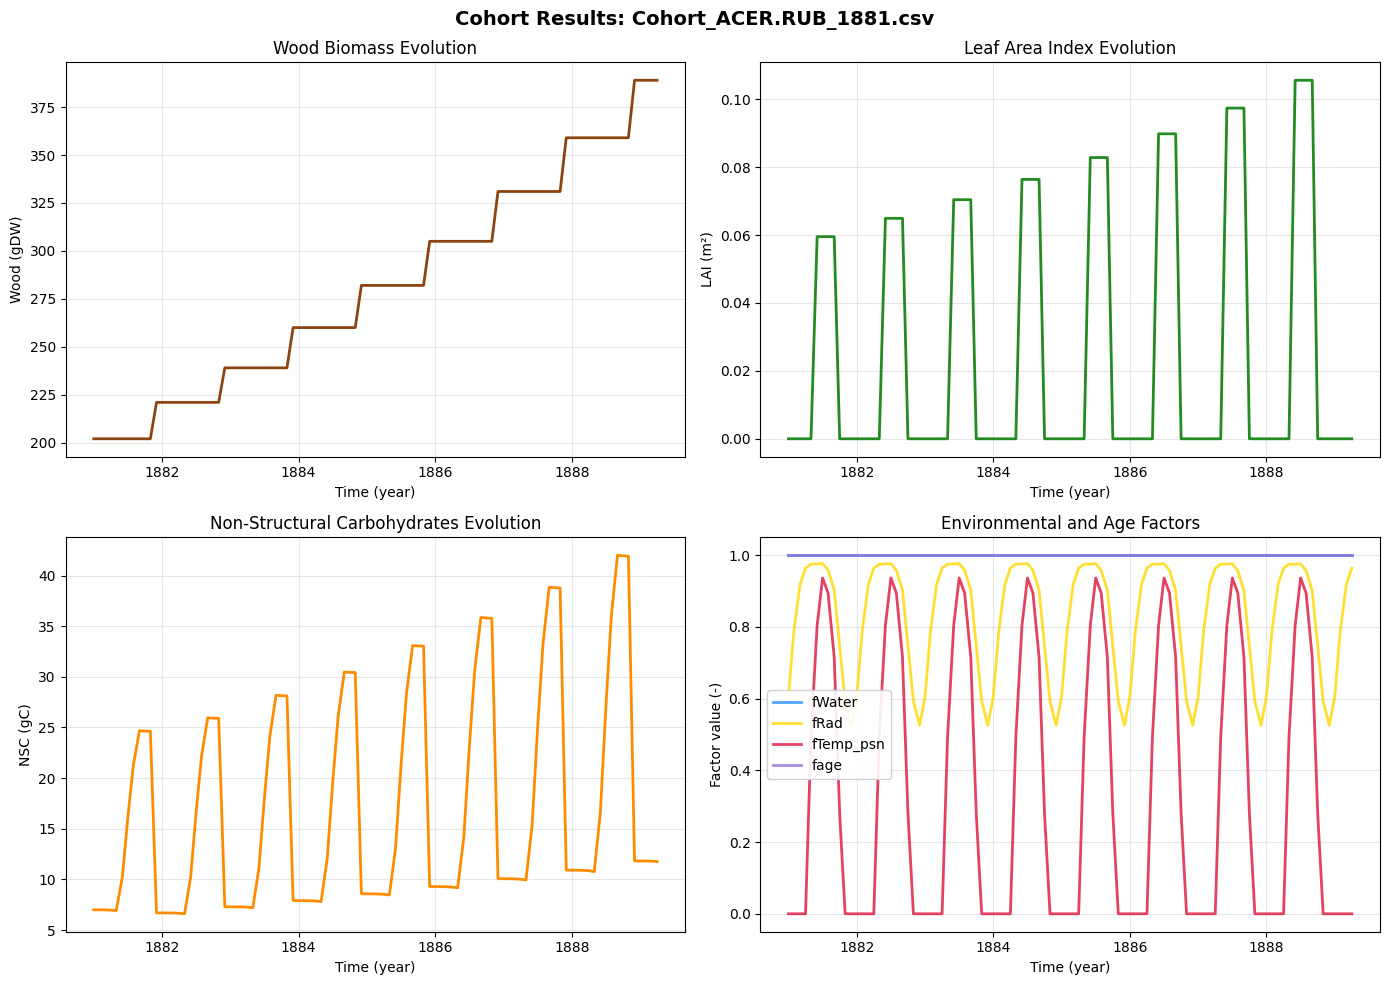

In [17]:
from functionsForCalibration import *

plot_single_cohort_results("/tmp/TestScenarioPnET/Output/Site1/Cohort_ABIE.BAL_1881.csv", monthsToKeep = 100)
plot_single_cohort_results("/tmp/TestScenarioPnET/Output/Site1/Cohort_ACER.RUB_1881.csv", monthsToKeep = 100)



Add a check for wood at age 14 for species competition on newly disturbed sites, as recommanded by Gustafson ?

In [23]:
import math

mainLayerPAR = 800
LAISummed = 5
LAIIndex = 4
k = 0.58 # 0.5 or 0.58 (abies or acer)

print(mainLayerPAR * math.exp(-k * (LAISummed - LAIIndex)))

447.91869325232165


In [22]:
import math

mainLayerPAR = 800
LAISummed = 5
LAIIndex = 4
k = 0.50 # 0.5 or 0.58 (abies or acer)

print(mainLayerPAR * math.exp(-k * (LAISummed - LAIIndex)))

485.22452777010676
